# How Antonelli Keeps Winning — Race Results (Chapter 2)

**Chapter 1** showed Antonelli usually out-qualifies his teammate — that's *getting to the front*. This chapter asks the next question: **how do those grids become wins?** Through Monaco he has won **5 of the last 6** (China, Japan, Miami, Canada, Monaco), losing only the Australia opener.

Same control as Chapter 1 — his teammate **Russell** (same car) — plus, for race pace, the **actual P2 finisher** of each race as a field reference (it varies by race). Sign convention throughout: **positive = Antonelli better** (more positions gained, faster pace, lower degradation). Clean lap = green-flag racing lap (`TrackStatus == '1'`, not lap 1, not an in/out/pit lap).

In [1]:
%matplotlib inline
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt

from src.loaders import setup_cache
from src import race
from src.season import RACES   # single source of truth (through Monaco)
from src.plotting import (plot_start_conversion, plot_stint_pace,
                          plot_gap_trace, plot_tire_deg)

setup_cache('../fastf1_cache')
RACES

['Australia', 'China', 'Japan', 'Miami', 'Canada', 'Monaco']

## The race record

Grid, lap-1 position, positions gained off the line, and finish for Antonelli at every round.

In [2]:
# Keyed by the RACES input string so the per-race P2 field reference can be
# looked up exactly in the pace cell below (not by fuzzy EventName match).
starts = {r: race.start_summary(2026, r) for r in RACES}
start = pd.concat(starts.values(), ignore_index=True)
start[start['driver'] == 'ANT'][['race','grid','lap1_pos','positions_gained','finish','status']]

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]


req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data


req            INFO 	Using cached data for lap_count


...

req            INFO 	Using cached data for _extended_timing_data


req            INFO 	Using cached data for timing_app_data


core           INFO 	Processing timing data...


core           INFO 	Finished loading data for 22 drivers: ['12', '44', '6', '81', '30', '41', '10', '23', '31', '14', '5', '63', '27', '43', '11', '55', '16', '18', '1', '87', '77', '3']


,race,grid,lap1_pos,positions_gained,finish,status
0,Australian Grand Prix,2.0,7.0,-5.0,2.0,Finished
3,Chinese Grand Prix,1.0,2.0,-1.0,1.0,Finished
6,Japanese Grand Prix,1.0,6.0,-5.0,1.0,Finished
9,Miami Grand Prix,1.0,2.0,-1.0,1.0,Finished
12,Canadian Grand Prix,2.0,2.0,0.0,1.0,Finished
15,Monaco Grand Prix,1.0,1.0,0.0,1.0,Finished


## Chapter A — Start & lap 1

Where each race is won or lost off the line and through the first lap.

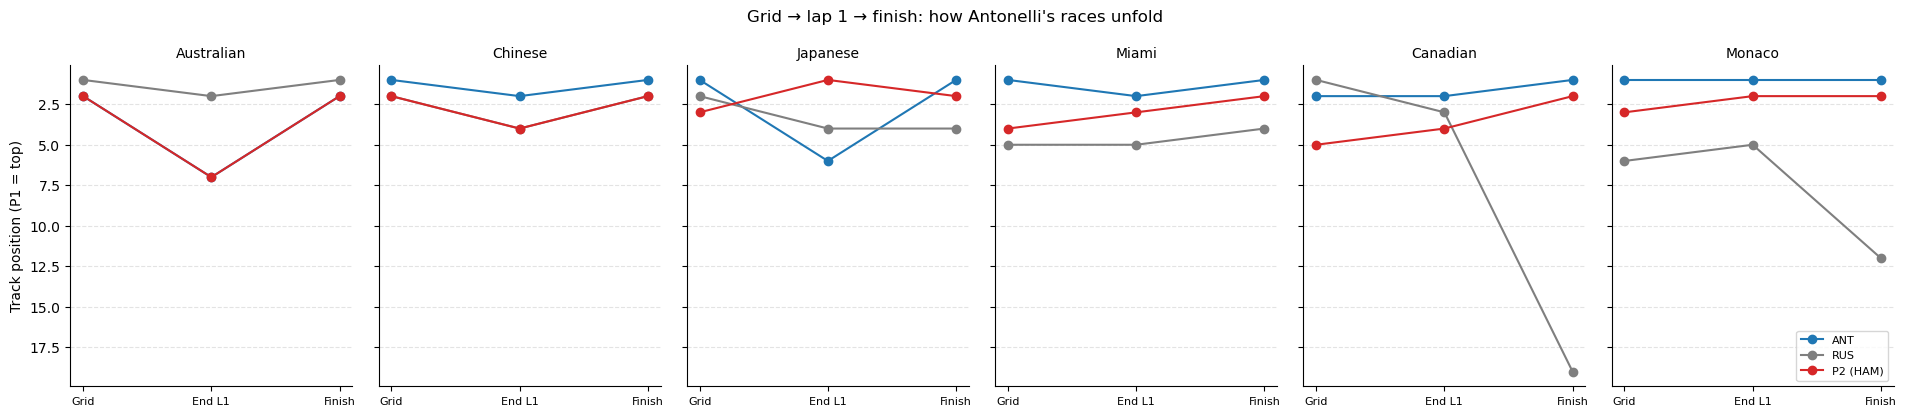

In [3]:
fig = plot_start_conversion(start, save_path='../figures/start_conversion.png'); plt.show()

Canada (R5) is the centerpiece: Antonelli started P2, led by lap 2, and won after Russell (on pole) retired — a win that was *converted* at the start and then *inherited* at the front. Monaco (R6) is the clean opposite: pole to flag-to-flag victory, no inheritance. Australia is the honest counter-case — P2 on the grid, P2 at the flag. That's a *finishing*-position loss, not a start failure: the front-row pace simply wasn't enough to pass Russell that day.

## Chapter B — Race pace & control

Median green-flag lap per stint (teammate + the per-race P2 finisher), then a per-lap gap trace.

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]


req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data


req            INFO 	Using cached data for lap_count


...

req            INFO 	Using cached data for track_status_data


req            INFO 	Using cached data for _extended_timing_data


req            INFO 	Using cached data for timing_app_data


core           INFO 	Processing timing data...


core           INFO 	Finished loading data for 22 drivers: ['12', '44', '6', '81', '30', '41', '10', '23', '31', '14', '5', '63', '27', '43', '11', '55', '16', '18', '1', '87', '77', '3']


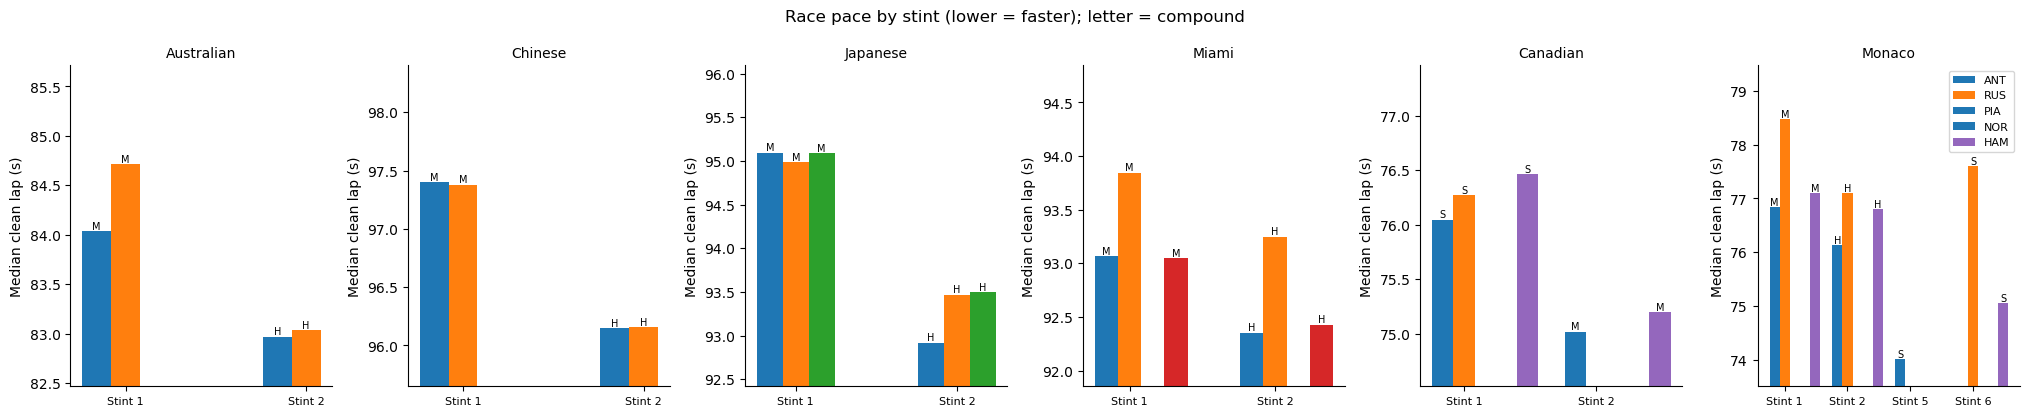

In [4]:
# Teammate pace + the per-race P2 finisher as field reference. The P2 code is
# read from each race's start summary (exact lookup, no fuzzy matching).
pace_frames = []
for r in RACES:
    p2_rows = starts[r][starts[r]['driver'] == 'P2']
    field = [p2_rows['code'].iloc[0]] if len(p2_rows) else []
    drivers = list(dict.fromkeys(['ANT', 'RUS'] + field))  # dedup if P2 is ANT/RUS
    pace_frames.append(race.stint_pace(2026, r, drivers))
pace = pd.concat(pace_frames, ignore_index=True)
fig = plot_stint_pace(pace, save_path='../figures/stint_pace.png'); plt.show()

Compare bars **within** a race and only across **matching compounds** (the letter on each bar). These are raw medians: they are **not** fuel-corrected, and stint timing and traffic differ between drivers — so read them as directional, not exact.

core           INFO 	Loading data for Chinese Grand Prix - Race [v3.8.1]


req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data


req            INFO 	Using cached data for lap_count


...

req            INFO 	Using cached data for track_status_data


req            INFO 	Using cached data for _extended_timing_data


req            INFO 	Using cached data for timing_app_data


core           INFO 	Processing timing data...


core           INFO 	Finished loading data for 22 drivers: ['12', '44', '6', '81', '30', '41', '10', '23', '31', '14', '5', '63', '27', '43', '11', '55', '16', '18', '1', '87', '77', '3']


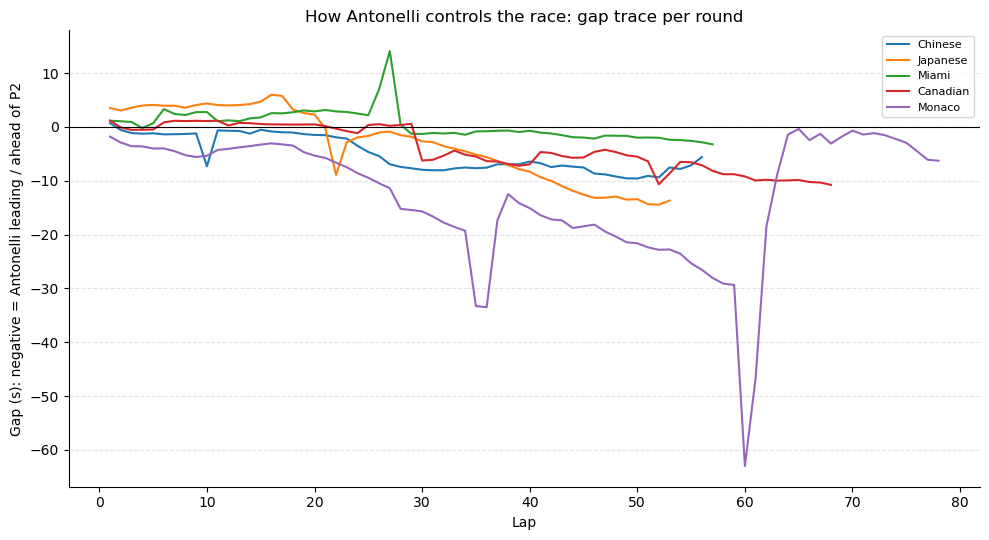

In [5]:
# Gap trace on the wins, where 'control' is the story. Negative = Antonelli
# leading (gap ahead of P2); positive = chasing (gap behind the leader).
gap = pd.concat([race.gap_to_rival(2026, r, 'ANT') for r in ['China','Japan','Miami','Canada','Monaco']],
                ignore_index=True)
fig = plot_gap_trace(gap, save_path='../figures/gap_trace.png'); plt.show()

At China, Japan, Miami and Monaco the trace sits below zero and *pulls away* — Antonelli leads and extends. Canada is the exception: the lead came partly inherited (Russell's retirement), which the honest-accounting note below names plainly.

## Chapter C — Tire degradation

Linear slope of clean-lap time vs tire age per stint (lower = better tire management). Stints with fewer than 5 clean laps report NaN rather than a noisy fitted number.

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]


req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data


req            INFO 	Using cached data for lap_count


...

req            INFO 	Using cached data for track_status_data


req            INFO 	Using cached data for _extended_timing_data


req            INFO 	Using cached data for timing_app_data


core           INFO 	Processing timing data...


core           INFO 	Finished loading data for 22 drivers: ['12', '44', '6', '81', '30', '41', '10', '23', '31', '14', '5', '63', '27', '43', '11', '55', '16', '18', '1', '87', '77', '3']


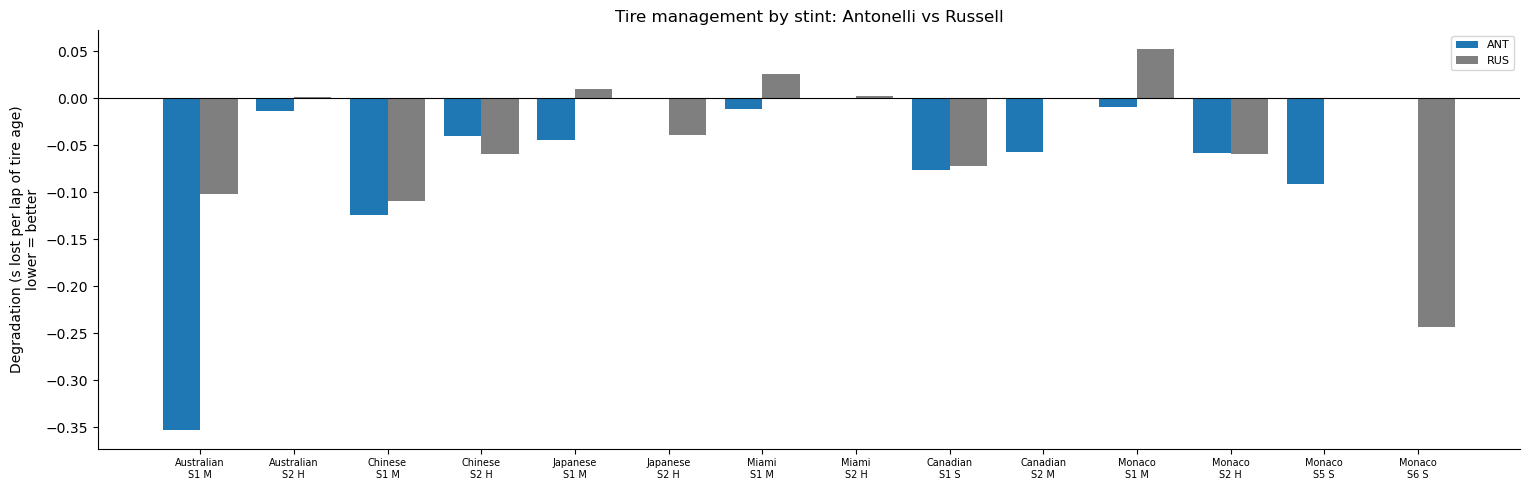

,race,driver,stint,compound,deg_slope_s_per_lap,n_clean
0,Australian Grand Prix,ANT,1,MEDIUM,-0.352550,9
1,Australian Grand Prix,ANT,2,HARD,-0.013633,40
2,Australian Grand Prix,RUS,1,MEDIUM,-0.101576,10
3,Australian Grand Prix,RUS,2,HARD,0.000661,40
4,Chinese Grand Prix,ANT,1,MEDIUM,-0.123893,8
5,Chinese Grand Prix,ANT,2,HARD,-0.040065,39
6,Chinese Grand Prix,RUS,1,MEDIUM,-0.109643,8
7,Chinese Grand Prix,RUS,2,HARD,-0.058989,39
8,Japanese Grand Prix,ANT,1,MEDIUM,-0.044729,20
9,Japanese Grand Prix,ANT,2,HARD,-0.000037,26


In [6]:
deg = pd.concat([race.tire_deg(2026, r, ['ANT', 'RUS']) for r in RACES], ignore_index=True)
fig = plot_tire_deg(deg, save_path='../figures/tire_deg.png'); plt.show()
deg  # includes NaN small-n stints, shown rather than hidden

Interpret only comparable **same-compound** stints. Fuel burn lowers lap times through a stint and partially offsets real degradation — that is **not** corrected for here, only named. Small-n stints are reported as NaN, never as zero.

## Honest accounting

- **Canada's win was partly inherited** — Russell led from pole and retired; Antonelli was P2 when it happened. Named, not hidden.
- **Six-race sample**, and the race mechanisms have even thinner data than the qualifying chapter. Directional, not conclusive.
- **Safety-car / VSC laps excluded everywhere** via the shared clean-lap filter.
- **No fuel-load, track-evolution, or strategy correction** — those factors are named as caveats, not modeled away.

## What this chapter shows

Qualifying gets Antonelli to the front (Chapter 1); here we see he generally *converts* the start and *controls* the race when he leads — most cleanly at Monaco, most luckily at Canada. Tire management is comparable to Russell's on like-for-like stints. The car is shared with Russell throughout, so what's left is mostly the driver — with the caveats above. **Chapter 3** zooms out across seasons to ask whether his strong tracks are driver tracks or car tracks.